In [1]:
import scanpy as sc

adata = sc.read_10x_mtx(
    "/Users/prashammarfatia/Downloads",  # This folder contains matrix.mtx, genes.tsv, barcodes.tsv
    var_names="gene_symbols", 
    cache=True
)

# View the AnnData object summary
print(adata)

AnnData object with n_obs × n_vars = 32991 × 36601
    var: 'gene_ids'


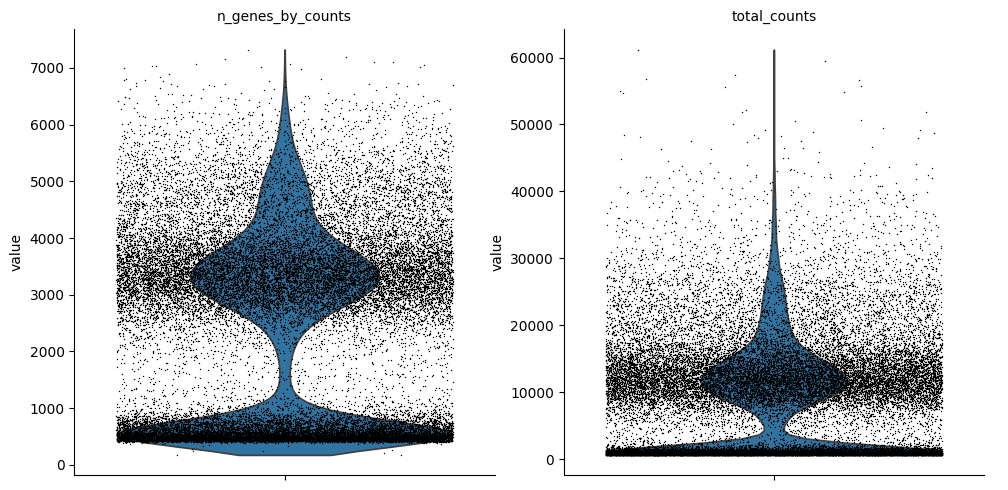

In [2]:
adata.raw = adata  # Backup raw counts
sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)


In [3]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [4]:
adata[:10, :10].to_df()

,AL627309.1,AL627309.5,AL627309.4,AP006222.2,AL669831.2,LINC01409,FAM87B,LINC01128,LINC00115,FAM41C
AAACCCAAGAAGTCAT-1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
AAACCCAAGACACACG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAAGAGGACTC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAAGCATGATA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAAGCGTATAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAAGGTAAAGG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAAGTTCGCAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCACAAATTGGA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCACAAGCTGCC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCACAATCGCAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
import pandas as pd

guide_path = "/Users/prashammarfatia/Downloads/GSM6435403_scRNAseq_2kG_11AMDox_1_noguidemut_calls.tsv.gz"

guide_df = pd.read_csv(guide_path, sep="\t")

guide_df.head()

,Unnamed: 0,CBC_10x,Guide,Gene,UMI_count,Good_singlet,Multiplet
0,6,AAACCCAAGAAGTCAT,GAAGGGACATCATTCACGCCT,ANKEF1,10,1,1
1,10,AAACCCAAGACACACG,GCCCTTCGTGGCCGCCCGGCG,CBX3,1,0,0
2,29,AAACCCAAGAGGACTC,GTGGTCCTGGGTACCGAGCAT,MTRR,13,1,1
3,69,AAACCCAAGCATGATA,NaN,NaN,0,0,0
4,95,AAACCCAAGCGTATAA,GCCAGGCTTCGTGGGACCAAC,DALRD3-TSS2,1,0,0


In [6]:
# 1. First, make sure barcodes are consistent (with the "-1" suffix)
guide_df["barcode"] = guide_df["CBC_10x"] + "-1"

# 2. Set index for the guide_df to barcodes
guide_df.set_index("barcode", inplace=True)

# 3. Subset guide_df to only cells present in adata
guide_df_sub = guide_df.loc[adata.obs_names.intersection(guide_df.index)]

# 4. Align the order of guide_df to match adata.obs
guide_df_sub = guide_df_sub.loc[adata.obs_names]

# 5. Add the relevant columns (Guide, Gene) to adata.obs
adata.obs["Guide"] = guide_df_sub["Guide"]
adata.obs["Gene"] = guide_df_sub["Gene"]

In [7]:
adata.obs[["Guide", "Gene"]].head(10)

,Guide,Gene
AAACCCAAGAAGTCAT-1,GAAGGGACATCATTCACGCCT,ANKEF1
AAACCCAAGACACACG-1,GCCCTTCGTGGCCGCCCGGCG,CBX3
AAACCCAAGAGGACTC-1,GTGGTCCTGGGTACCGAGCAT,MTRR
AAACCCAAGCATGATA-1,NaN,NaN
AAACCCAAGCGTATAA-1,GCCAGGCTTCGTGGGACCAAC,DALRD3-TSS2
AAACCCAAGGTAAAGG-1,GCGGCCGAGTTGGGAGAATG,GALNT2
AAACCCAAGTTCGCAT-1,NaN,NaN
AAACCCACAAATTGGA-1,NaN,NaN
AAACCCACAAGCTGCC-1,NaN,NaN
AAACCCACAATCGCAT-1,GATGCGCCCTGCCCGGCGTGC,JAG1


In [8]:
import scanpy as sc

# Basic quality control
adata.var_names_make_unique()

# Calculate QC metrics
adata.obs['n_counts'] = adata.X.sum(axis=1).A1  # Total counts per cell
adata.obs['n_genes'] = (adata.X > 0).sum(axis=1).A1  # Genes expressed per cell

# Filter cells
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalize & log transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]

# Scale data
sc.pp.scale(adata, max_value=10)


/Users/prashammarfatia/.virtualenvs/py311/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [9]:
print(adata.obs.columns)
print(adata.var_names[:10])

Index(['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'n_genes', 'Guide', 'Gene', 'n_counts'],
      dtype='object')
Index(['LINC01409', 'LINC01128', 'C1orf159', 'ACAP3', 'PUSL1', 'VWA1',
       'ATAD3B', 'ATAD3A', 'TMEM240', 'FNDC10'],
      dtype='object')


In [10]:
print(adata.obs['Gene'].nunique())

2570


In [11]:
print(adata.obs['Guide'].nunique())

12378


/Users/prashammarfatia/.virtualenvs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/cf/j3zfmms55hd1g9sckt0nw0s00000gp/T/ipykernel_90791/3240844278.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)
saving figure to file figures/umap_leiden_top20guides.png


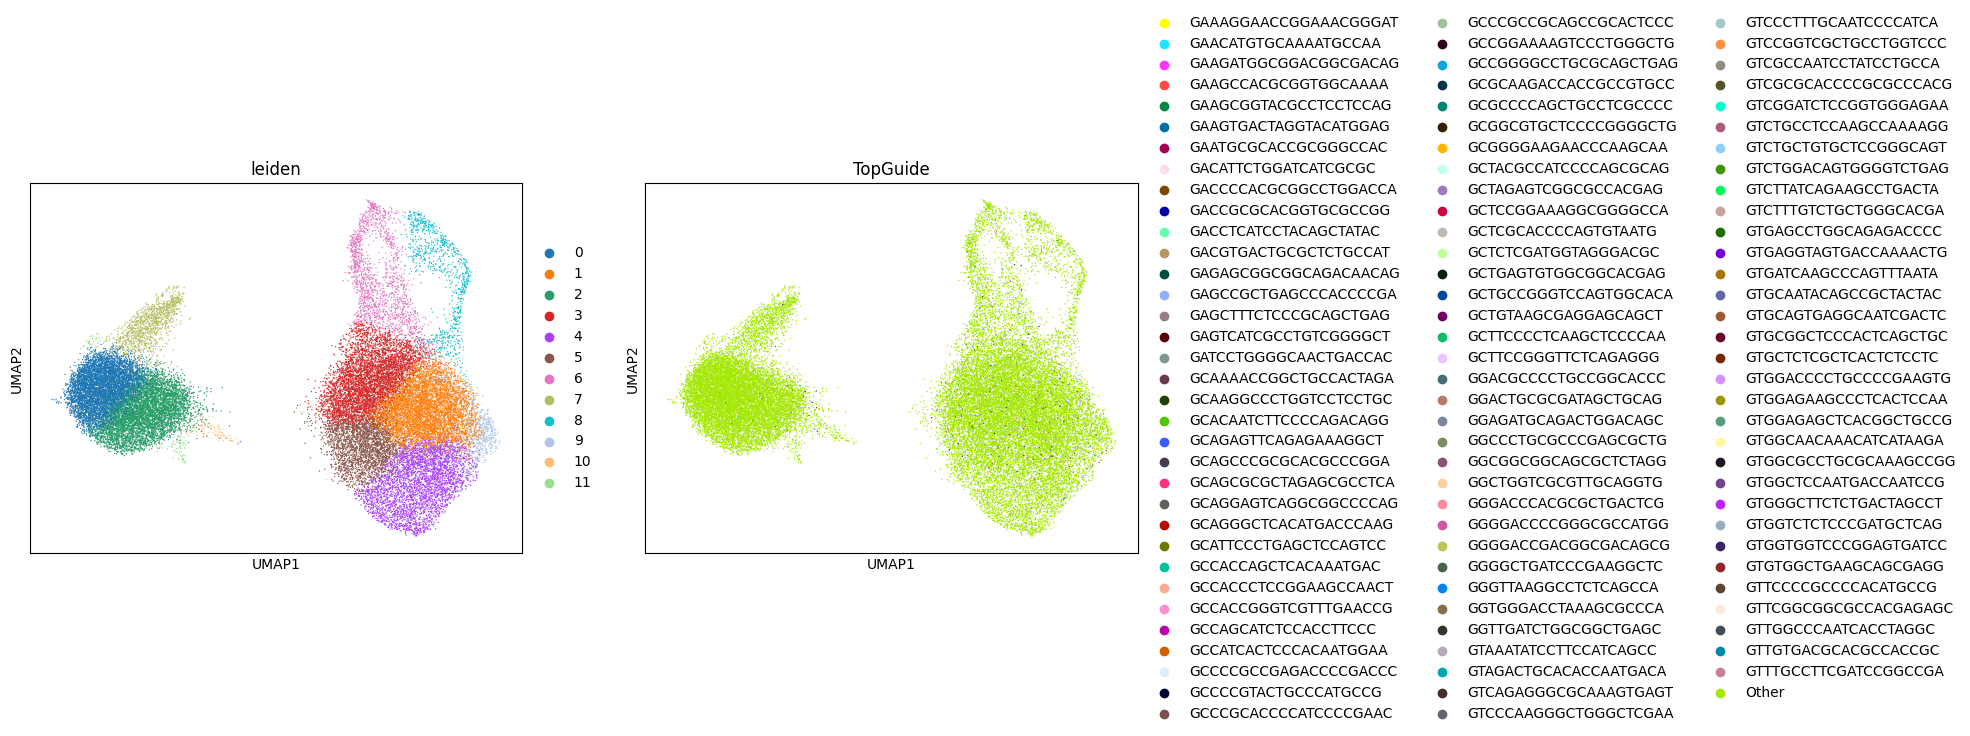

In [12]:
# PCA
sc.tl.pca(adata, svd_solver='arpack')

# Neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Clustering
sc.tl.leiden(adata)

# UMAP
sc.tl.umap(adata)

# Plot top N most frequent guides
top_n = 100
top_guides = adata.obs['Guide'].value_counts().head(top_n).index.tolist()
adata.obs['TopGuide'] = adata.obs['Guide'].apply(lambda x: x if x in top_guides else 'Other')

# UMAP with Leiden and Top 20 Guides
sc.pl.umap(adata, color=['leiden', 'TopGuide'], save="_leiden_top20guides.png")


In [13]:
for cluster in adata.obs['leiden'].unique():
    guides = adata.obs.loc[adata.obs['leiden'] == cluster, 'Guide'].value_counts().head(5)
    print(f"Cluster {cluster} top guides:")
    print(guides)
    print()

Cluster 1 top guides:
Guide
GACATTCTGGATCATCGCGC     5
GGGGCTGATCCCGAAGGCTC     5
GTGGACCCCTGCCCCGAAGTG    5
GTTGGCTGGCCCCTGTGCGTG    4
GCGAAGGCTGTGCGGTCTGCC    4
Name: count, dtype: int64

Cluster 5 top guides:
Guide
GCGGCGTGCTCCCCGGGGCTG    4
GCGGCGCTGACGCAGCCATGG    4
GCACAACACACCCAACTGCA     3
GCTTCCATGGCTGTGTCTCCA    3
GCGCGCGGCCGGCGAGAGTAA    3
Name: count, dtype: int64

Cluster 2 top guides:
Guide
GTGCTCCGCAGCAGCCGGGCC    3
GCAGCCGAAGCCGGAGTCGCG    2
GCACACTCTCCCATCACTCAA    2
GTGACGCGGCATCTGCTGCAG    2
GCGCGGCCGGGCGCTTACCTG    2
Name: count, dtype: int64

Cluster 6 top guides:
Guide
GCCTACAGGGCGGAAACCAC     3
GCGGGTCAAGAGCCCCACGCC    2
GAAGCCAGCCACGCGCCTGCG    2
GTTCGGCGGCGCCACGAGAGC    2
GCGGCGTCGCTGCCACCATGA    2
Name: count, dtype: int64

Cluster 0 top guides:
Guide
GTTCAGCTGCTGCCACCAGCC    2
GTAAGGGGCGTGGCGCCAGT     2
GACACTGGGTGTAGCACCCAG    1
GCCTGGCCCCGCCCCTTGACT    1
GTACCGAGGTGCGCAGGGTG     1
Name: count, dtype: int64

Cluster 4 top guides:
Guide
GTGGGCTTCTCTGACTAGCCT 

In [14]:
for cluster in adata.obs['leiden'].unique():
    genes = adata.obs.loc[adata.obs['leiden'] == cluster, 'Gene'].value_counts().head(5)
    print(f"Cluster {cluster} top genes:")
    print(genes)
    print()

Cluster 1 top genes:
Gene
safe-targeting      76
negative-control    63
ANKEF1               9
LMAN1                8
COASY                8
Name: count, dtype: int64

Cluster 5 top genes:
Gene
safe-targeting      33
negative-control    26
FYCO1                8
MTIF3-TSS2           6
KLF4                 6
Name: count, dtype: int64

Cluster 2 top genes:
Gene
safe-targeting      18
negative-control    17
EHD4                 5
PTK7                 4
RAD50                4
Name: count, dtype: int64

Cluster 6 top genes:
Gene
safe-targeting      26
negative-control    14
MRPL3                6
TBC1D10B             5
TP53                 5
Name: count, dtype: int64

Cluster 0 top genes:
Gene
negative-control    4
safe-targeting      3
AMZ2                3
CLPX                2
WBP2                2
Name: count, dtype: int64

Cluster 4 top genes:
Gene
safe-targeting                   49
negative-control                 21
Enhancer-at-CAD-SNP-rs9337951     7
Enhancer-at-CAD-SNP-rs4724806  

In [15]:
print("Shape of adata (cells x genes):", adata.shape)

Shape of adata (cells x genes): (32989, 3960)


In [16]:
# b) Cell-level metadata (obs)
print("\n Cell metadata (first 5 rows):")
display(adata.obs.head())



 Cell metadata (first 5 rows):


,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,n_genes,Guide,Gene,n_counts,leiden,TopGuide
AAACCCAAGAAGTCAT-1,3675,8.209580,12543.0,9.436997,28.725185,40.556486,50.570039,63.254405,3675,GAAGGGACATCATTCACGCCT,ANKEF1,12543.0,1,Other
AAACCCAAGACACACG-1,3881,8.264106,13993.0,9.546384,28.578575,40.191524,50.246552,63.267348,3880,GCCCTTCGTGGCCGCCCGGCG,CBX3,13992.0,1,Other
AAACCCAAGAGGACTC-1,1931,7.566311,5770.0,8.660601,32.287695,47.227036,58.908146,72.876950,1931,GTGGTCCTGGGTACCGAGCAT,MTRR,5770.0,5,Other
AAACCCAAGCATGATA-1,468,6.150603,699.0,6.551080,33.619456,47.353362,61.659514,100.000000,468,NaN,NaN,699.0,2,Other
AAACCCAAGCGTATAA-1,3526,8.168203,12679.0,9.447782,27.068381,39.309094,50.114362,63.782633,3526,GCCAGGCTTCGTGGGACCAAC,DALRD3-TSS2,12679.0,6,Other


In [17]:
# Gene-level metadata (var)
print("\n Gene metadata (first 5 rows):")
display(adata.var.head())



 Gene metadata (first 5 rows):


,gene_ids,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm,mean,std
LINC01409,ENSG00000237491,1652,0.052984,0.051628,94.992574,1748.0,7.466799,1652,True,0.061978,1.709696,0.650285,0.032299,0.174410
LINC01128,ENSG00000228794,1954,0.063290,0.061368,94.077173,2088.0,7.644441,1954,True,0.069513,1.645980,0.569722,0.037360,0.183400
C1orf159,ENSG00000131591,893,0.027523,0.027151,97.293201,908.0,6.812345,893,True,0.032884,1.701989,0.640541,0.016971,0.126332
ACAP3,ENSG00000131584,985,0.030948,0.030479,97.014337,1021.0,6.929517,985,True,0.036614,1.691017,0.626668,0.018864,0.133905
PUSL1,ENSG00000169972,3543,0.117790,0.111353,89.260707,3886.0,8.265393,3542,True,0.124819,1.602766,0.515081,0.069570,0.245559


In [18]:
import scipy
# Subset of the expression matrix (first 5 cells x first 5 genes)
print("\n Expression matrix subset (first 5 cells × first 5 genes):")
subset_matrix = adata.X[:5, :5].toarray() if scipy.sparse.issparse(adata.X) else adata.X[:5, :5]
subset_df = pd.DataFrame(subset_matrix,
                         index=adata.obs_names[:5],
                         columns=adata.var_names[:5])
display(subset_df)


 Expression matrix subset (first 5 cells × first 5 genes):


,LINC01409,LINC01128,C1orf159,ACAP3,PUSL1
AAACCCAAGAAGTCAT-1,3.176220,-0.203706,-0.134337,-0.140877,-0.283313
AAACCCAAGACACACG-1,-0.185189,-0.203706,-0.134337,-0.140877,-0.283313
AAACCCAAGAGGACTC-1,-0.185189,-0.203706,-0.134337,-0.140877,-0.283313
AAACCCAAGCATGATA-1,-0.185189,-0.203706,-0.134337,-0.140877,-0.283313
AAACCCAAGCGTATAA-1,-0.185189,-0.203706,-0.134337,-0.140877,-0.283313


In [19]:
# Count how many cells per gene perturbation
gene_cell_counts = adata.obs["Gene"].value_counts()

# Preview top 10 genes with the most cells knocked down
print("Top 10 genes with the most cells:")
print(gene_cell_counts.head(10))

# How many total gene perturbations?
print("\nTotal unique genes perturbed:", gene_cell_counts.shape[0])

# How many genes have >= 50 cells?
print("\nGenes with at least 50 cells:", (gene_cell_counts >= 50).sum())

Top 10 genes with the most cells:
Gene
safe-targeting      302
negative-control    205
SMAD3                21
XPO7                 21
ECM1                 21
RAB1A                20
COASY                20
BMPER                20
PDE3A                19
CLIC1                19
Name: count, dtype: int64

Total unique genes perturbed: 2570

Genes with at least 50 cells: 2


In [20]:
print("Top 100 genes with the most cells:")
print(gene_cell_counts.head(100))

Top 100 genes with the most cells:
Gene
safe-targeting      302
negative-control    205
SMAD3                21
XPO7                 21
ECM1                 21
                   ... 
IBTK                 15
AACS                 15
TSR1                 15
SETD1A               15
DST                  15
Name: count, Length: 100, dtype: int64


In [21]:
gene_counts = adata.obs['Gene'].value_counts()
genes_with_15_or_more = gene_counts[gene_counts >= 10]
print(f"Number of genes with at least 10 cells: {len(genes_with_15_or_more)}")

Number of genes with at least 10 cells: 655


/Users/prashammarfatia/.virtualenvs/py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
adata.X seems to be already log-transformed.
/Users/prashammarfatia/.virtualenvs/py311/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:392: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


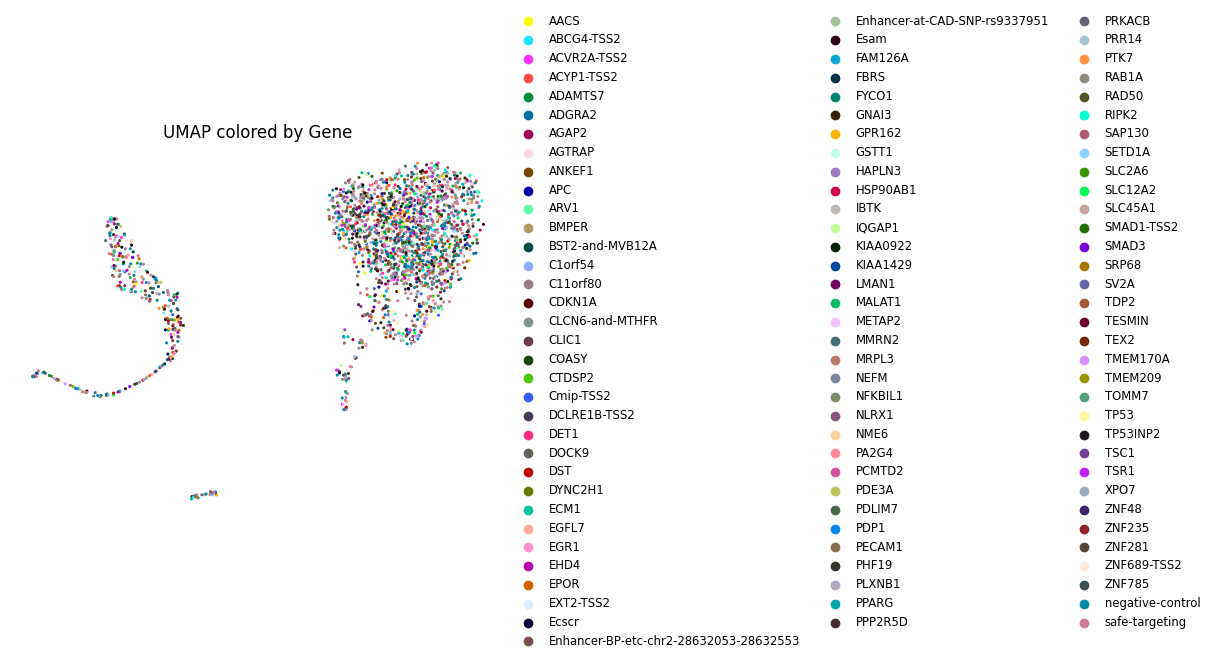

In [22]:
import scanpy as sc
import numpy as np

# Filter to genes with at least 15 cells
genes_with_15_or_more_cells = adata.obs['Gene'].value_counts()
selected_genes = genes_with_15_or_more_cells[genes_with_15_or_more_cells >= 15].index.tolist()
adata_subset = adata[adata.obs['Gene'].isin(selected_genes)].copy()

# Optional: save the raw counts for reference
adata_subset.raw = adata_subset

# Step 2: Ensure there are no all-zero genes
sc.pp.filter_genes(adata_subset, min_cells=1)

# Step 3: Normalize, log1p, and handle NaNs
sc.pp.normalize_total(adata_subset, target_sum=1e4)
sc.pp.log1p(adata_subset)
adata_subset.X = np.nan_to_num(adata_subset.X)

# Step 4: Identify highly variable genes
sc.pp.highly_variable_genes(adata_subset, n_top_genes=2000, flavor='seurat', subset=True)

# Step 5: Scale, PCA, neighbors, and UMAP
sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, svd_solver='arpack')
sc.pp.neighbors(adata_subset, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_subset)

# Step 6: Plot UMAP with color by perturbed gene
adata_subset.obs['Gene'] = adata_subset.obs['Gene'].astype('category')
sc.pl.umap(
    adata_subset,
    color='Gene',
    legend_loc='right margin',  
    legend_fontsize='small',
    palette=sc.pl.palettes.default_102,  # For enough unique colors
    title='UMAP colored by Gene',
    frameon=False,
    size=20
)


In [23]:
print(adata_subset.raw)

Raw AnnData with n_obs × n_vars = 2127 × 3960
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    varm: 'PCs'


In [24]:
print(adata_subset.raw.X.shape)
print(adata_subset.raw.var_names[:5])


(2127, 3960)
Index(['LINC01409', 'LINC01128', 'C1orf159', 'ACAP3', 'PUSL1'], dtype='object')


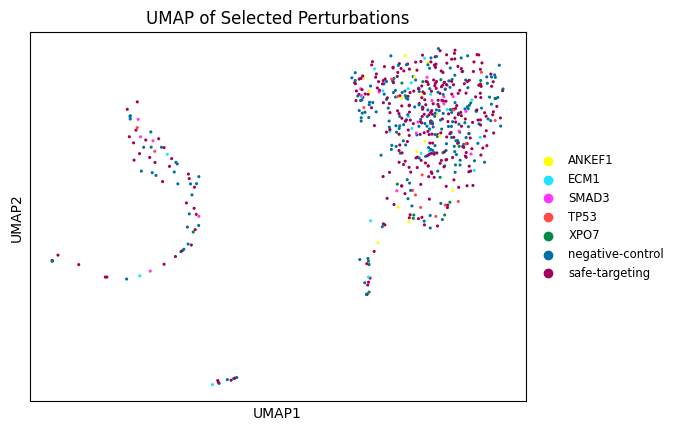

In [25]:
import scanpy as sc

# Pick top genes of interest (adjust this list based on your experiment)
top_genes = ['safe-targeting', 'negative-control', 'TP53', 'XPO7', 'SMAD3', 'ECM1', 'ANKEF1']

# Filter the subset
adata_trimmed = adata_subset[adata_subset.obs['Gene'].isin(top_genes)].copy()

# Plot UMAP
sc.pl.umap(adata_trimmed, color='Gene', legend_loc='right margin', legend_fontsize='small',
    palette=sc.pl.palettes.default_102, size=20, title='UMAP of Selected Perturbations')

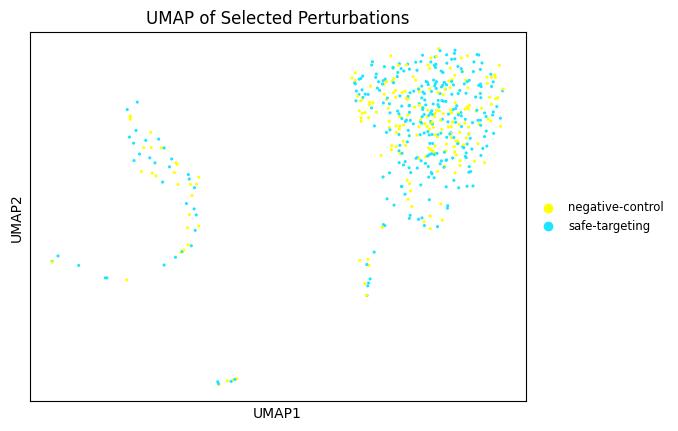

In [26]:
import scanpy as sc

# Pick top genes of interest (adjust this list based on your experiment)
top_genes2 = ['safe-targeting', 'negative-control']

# Filter the subset
adata_trimmed2 = adata_subset[adata_subset.obs['Gene'].isin(top_genes2)].copy()

# Plot UMAP
sc.pl.umap(adata_trimmed2, color='Gene', legend_loc='right margin', legend_fontsize='small',
    palette=sc.pl.palettes.default_102, size=20, title='UMAP of Selected Perturbations')

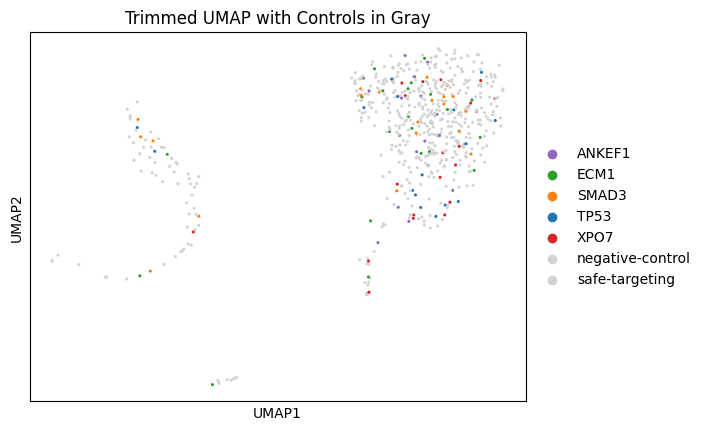

In [27]:
top_genes = ['safe-targeting', 'negative-control', 'TP53', 'SMAD3', 'ECM1', 'XPO7', 'ANKEF1']
color_map = {
    'safe-targeting': 'lightgray',
    'negative-control': 'lightgray',
    'TP53': '#1f77b4',
    'SMAD3': '#ff7f0e',
    'ECM1': '#2ca02c',
    'XPO7': '#d62728',
    'ANKEF1': '#9467bd'
}

adata_trimmed = adata_subset[adata_subset.obs['Gene'].isin(top_genes)].copy()
colors = [color_map[gene] for gene in adata_trimmed.obs['Gene'].cat.categories]

sc.pl.umap(adata_trimmed, color='Gene', palette=colors, size=20,
           legend_loc='right margin', title='Trimmed UMAP with Controls in Gray')

In [28]:
import scanpy as sc
import numpy as np

# STEP 0: Reload original adata if needed
adata_raw = adata.raw.to_adata() if adata.raw is not None else adata.copy()

In [29]:
#Preprocessing with 1000 HVGs
sc.pp.filter_genes(adata_raw, min_cells=1)
sc.pp.normalize_total(adata_raw, target_sum=1e4)
sc.pp.log1p(adata_raw)
adata_raw.X = np.nan_to_num(adata_raw.X)
sc.pp.highly_variable_genes(adata_raw, n_top_genes=1000, flavor='seurat', subset=True)

# Dimensionality reduction
sc.pp.scale(adata_raw, max_value=10)
sc.tl.pca(adata_raw, svd_solver='arpack')
sc.pp.neighbors(adata_raw, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_raw)

adata.X seems to be already log-transformed.
/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


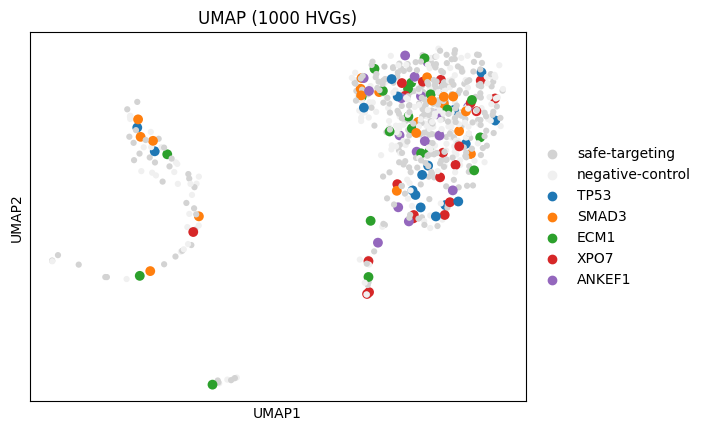

In [30]:
# Define gene categories and corresponding colors
top_genes = ['safe-targeting', 'negative-control', 'TP53', 'SMAD3', 'ECM1', 'XPO7', 'ANKEF1']
color_map = {
    'safe-targeting': '#d3d3d3',  # light gray
    'negative-control': '#f0f0f0',  # even lighter gray
    'TP53': '#1f77b4',
    'SMAD3': '#ff7f0e',
    'ECM1': '#2ca02c',
    'XPO7': '#d62728',
    'ANKEF1': '#9467bd'
}

# Make Gene a categorical with correct ordering
adata_trimmed.obs['Gene'] = adata_trimmed.obs['Gene'].astype('category')
adata_trimmed.obs['Gene'] = adata_trimmed.obs['Gene'].cat.set_categories(top_genes)

# Set colors and sizes
palette = [color_map[g] for g in adata_trimmed.obs['Gene'].cat.categories]
sizes = adata_trimmed.obs['Gene'].map(lambda g: 80 if g in ['safe-targeting', 'negative-control'] else 200)

# Plot UMAP
sc.pl.umap(
    adata_trimmed,
    color='Gene',
    palette=palette,
    size=sizes.values,
    legend_loc='right margin',
    title='UMAP (1000 HVGs)'
)

In [31]:
import scanpy as sc
import pandas as pd
from collections import Counter

deg_results = {}

perturbations = [
    gene for gene, count in Counter(adata.obs['Gene']).items()
    if gene is not None and gene != 'negative-control' and count >= 15
]

for pert in perturbations:
    try:
        # Subset and recover full gene matrix from raw
        adata_subset = adata[adata.obs['Gene'].isin([pert, 'negative-control'])].copy()
        adata_subset = adata_subset.raw.to_adata()

        # Assign group for DEG comparison
        adata_subset.obs['group'] = (adata[adata_subset.obs_names].obs['Gene'] == pert).astype(str)

        # Normalize + log1p
        sc.pp.normalize_total(adata_subset, target_sum=1e4)
        sc.pp.log1p(adata_subset)

        # Perform DEG
        sc.tl.rank_genes_groups(adata_subset, groupby='group', method='wilcoxon', reference='False')
        deg_df = sc.get.rank_genes_groups_df(adata_subset, group='True')

        # Optional filtering
        deg_df_filtered = deg_df[
            (deg_df['pvals_adj'] < 0.05) & (deg_df['logfoldchanges'].abs() > 0.25)
        ]

        deg_results[pert] = deg_df_filtered
        top_gene = deg_df_filtered.iloc[0]['names'] if not deg_df_filtered.empty else "None"
        print(f"✓ Finished DEG for: {pert} (top DEG: {top_gene})")

    except Exception as e:
        print(f"❌ DEG failed for {pert}: {e}")

successful_degs = {
    k: v for k, v in deg_results.items()
    if isinstance(v, pd.DataFrame) and not v.empty
}
print(f"\n✅ DEG successfully computed for {len(successful_degs)} perturbations.")


adata.X seems to be already log-transformed.


✓ Finished DEG for: ANKEF1 (top DEG: None)


adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.


❌ DEG failed for nan: 'NoneType' object has no attribute 'columns'


adata.X seems to be already log-transformed.


...

✓ Finished DEG for: TSR1 (top DEG: None)


adata.X seems to be already log-transformed.


✓ Finished DEG for: SMAD1-TSS2 (top DEG: None)


adata.X seems to be already log-transformed.


✓ Finished DEG for: ADAMTS7 (top DEG: None)
✓ Finished DEG for: ACVR2A-TSS2 (top DEG: None)

✅ DEG successfully computed for 1 perturbations.


In [32]:
# Try this after the loop
sample_pert = "TP53"  # or any other you want to check
adata_subset = adata[adata.obs['Gene'].isin([sample_pert, 'negative-control'])].copy()
adata_subset = adata_subset.raw.to_adata()
adata_subset.obs['group'] = (adata[adata_subset.obs_names].obs['Gene'] == sample_pert).astype(str)

# Skip normalization and log1p if already done
sc.tl.rank_genes_groups(adata_subset, groupby='group', method='wilcoxon', reference='False')
df = sc.get.rank_genes_groups_df(adata_subset, group='True')

# Show top results
df.head(10)


It seems you use rank_genes_groups on the raw count data. Please logarithmize your data before calling rank_genes_groups.


,names,scores,logfoldchanges,pvals,pvals_adj
0,NCAPD3,2.878356,2.972056,0.003998,1.0
1,PUF60,2.815484,1.735051,0.004870,1.0
2,DNAJC2,2.762435,1.755235,0.005737,1.0
3,STMN1,2.748682,2.320954,0.005984,1.0
4,YDJC,2.732964,1.783509,0.006277,1.0
5,AASS,2.681881,1.418890,0.007321,1.0
6,VEZF1,2.624903,1.937831,0.008667,1.0
7,DEK,2.579714,1.627363,0.009888,1.0
8,BIRC5,2.575784,2.167913,0.010001,1.0
9,POLD2,2.536489,1.620424,0.011197,1.0


In [35]:
print(f"adata dimensions  : {adata.shape}")

adata dimensions  : (32989, 3960)


In [36]:
import pandas as pd
from collections import Counter

cell_counts = Counter(adata.obs["Gene"])
summary = (pd.Series(cell_counts)
             .rename_axis("Perturbation")
             .reset_index(name="n_cells")
             .sort_values("n_cells", ascending=False))
display(summary.head())        # top few
print(summary["n_cells"].describe())

# How many conditions reach the 15-cell cut-off?
valid = summary.query("n_cells >= 15")
print(f"{len(valid)} perturbations have ≥15 cells")


,Perturbation,n_cells
3,NaN,13683
111,safe-targeting,302
174,negative-control,205
116,ECM1,21
440,XPO7,21


count     2571.000000
mean        12.831194
std        269.821942
min          1.000000
25%          5.000000
50%          7.000000
75%         10.000000
max      13683.000000
Name: n_cells, dtype: float64
101 perturbations have ≥15 cells


In [37]:
print("\n.obs columns:")
print(list(adata.obs.columns))

# Show distinct values for plate / batch-like columns if present
for col in ["batch", "plate", "well", "run", "lane"]:
    if col in adata.obs:
        print(f"\n{col} → unique entries:", adata.obs[col].unique()[:10])


.obs columns:
['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'Guide', 'Gene', 'n_counts', 'leiden', 'TopGuide']
